In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
import flopy
from modflowapi import ModflowApi
import xmf6

In [2]:
# --- Componentes ---

# Parámetros de la simulación (flopy.mf6.MFSimulation)
init = {
    'sim_name' : "flow",
    'exe_name' : "C:\\Users\\luiggi\\Documents\\GitSites\\xmf6\\mf6\\windows\\mf6",
#    'exe_name' : "../../mf6/macosarm/mf6",
    'sim_ws' : "test2"
}

# Parámetros para el tiempo (flopy.mf6.ModflowTdis)
tdis = {
    'units': "DAYS",
    'nper' : 1,
    'perioddata': [(1.0, 1, 1.0)]
}

# Parámetros para la solución numérica (flopy.mf6.ModflowIms)
ims = {}

# Parámetros para el modelo de flujo (flopy.mf6.ModflowGwf)
gwf = { 
    'modelname': init["sim_name"],
    'model_nam_file': f"{init["sim_name"]}.nam",
    'save_flows': True
}

# --- Paquetes del modelo de flujo ---
lx = 25
ly = 25
nrow = 2
ncol = 5
delr = lx / ncol
delc = ly / nrow 

# Parámetros para la discretización espacial (flopy.mf6.ModflowGwfdis)
dis = {
    'length_units': "meters",
    'nlay': 1, 
    'nrow': nrow, 
    'ncol': ncol,
    'delr': delr, 
    'delc': delc, 
    'top' : 1.0, 
    'botm': 0.0 
}

# Parámetros para las condiciones iniciales (flopy.mf6.ModflowGwfic)
ic = {
    'strt': 1.0
}

# Parámetros para las condiciones de frontera (flopy.mf6.ModflowGwfchd)
chd_data = []
for row in range(dis['nrow']):
    chd_data.append([(0, row, 0), 10.0])       # Condición en la pared izquierda
    chd_data.append([(0, row, dis['ncol'] - 1), 5.0]) # Condición en la pared derecha

chd = {
    'stress_period_data': chd_data,     
}

# Parámetros para las propiedades de flujo (flopy.mf6.ModflowGwfnpf)
npf = {
    'save_specific_discharge': True,
    'save_saturation' : True,
    'icelltype' : 0,
    'k' : 0.01,
}

# Parámetros para almacenar y mostrar la salida de la simulación (flopy.mf6.ModflowGwfoc)
oc = {
    'budget_filerecord': f"{init['sim_name']}.bud",
    'head_filerecord': f"{init['sim_name']}.hds",
    'saverecord': [("HEAD", "ALL"), ("BUDGET", "ALL")],
    'printrecord': [("HEAD", "ALL")]
}

# Inicialización de la simulación
o_sim, o_tdis, o_ims = xmf6.gwf.init_sim(init = init, tdis = tdis, ims = ims, silent = True)

# Configuración de los paquetes para el modelo de flujo
o_gwf, package_list = xmf6.gwf.set_packages(o_sim, silent = True,
                                            gwf = gwf, dis = dis, ic = ic, chd = chd, npf = npf, oc = oc)

# Escritura de los archivos de entrada
o_sim.write_simulation(silent = True)

In [3]:
def build_mat(mf6):
    """
    Construye la matriz del sistema.

    Parameters
    ----------
    mf6: ModflowApi
        Objeto para accedar a toda la funcionalidad de la API.
    """
    # Obtiene el número de renglones y columnas del sistema
    NCOL = mf6.get_value(mf6.get_var_address("NCOL", 'SLN_1'))
    NROW = mf6.get_value(mf6.get_var_address("NROW", 'SLN_1'))

    # Obtiene los coeficientes de la matriz en formato CRS (Compressed Row Storage)
    # A: Coeficientes, JA: índices de la columna, IA: índice de inicio del renglón en JA.
    A = mf6.get_value(mf6.get_var_address("AMAT", 'SLN_1'))
    IA = mf6.get_value(mf6.get_var_address("IA", 'SLN_1'))
    JA = mf6.get_value(mf6.get_var_address("JA", 'SLN_1'))

    # Arreglo para almacenar la matriz en formato completo.
    Atest = np.zeros((NROW[0], NCOL[0]))
    idx = 0
    i = 0
    istart = IA[0] # Inicio del renglón en IA
    for iend in IA[1:]: # Recorremos desde el inicio de cada renglón
        for j in range(istart, iend): # Recorremos todos los elementos del renglón
            Atest[idx, JA[j-1]-1] = A[i] # Agregamos el coeficiente en la matriz completa
            i += 1
        istart = iend
        idx += 1
    return Atest, A, IA, JA # Regresamos la matriz densa y en el format CRS

In [4]:
OS = sys.platform
if OS == "win32":
    mf6_lib = "libmf6.dll"
elif OS == "darwin":
    mf6_lib = "libmf6.dylib"
else:
    mf6_lib = "libmf6.so"

# Rutas a la biblioteca compartida y al archivo de configuración
mf6_lib_path = os.path.abspath(os.path.join("..", "..", "mf6", "windows", mf6_lib))
mf6_config_file = os.path.join(o_sim.sim_path, 'mfsim.nam')
print("Shared library:", mf6_lib_path)
print("Config file:", mf6_config_file)

# Objeto para acceder a toda la funcionalidad de la API
mf6 = ModflowApi(mf6_lib_path, working_directory=o_sim.sim_path)

# Inicialización del modelo
mf6.initialize(mf6_config_file)

Shared library: C:\Users\luiggi\Documents\GitSites\xmf6\mf6\windows\libmf6.dll
Config file: C:\Users\luiggi\Documents\GitSites\xmf6\examples\10_mf6_api\test2\mfsim.nam


In [5]:
# Para la solución obtenida con np.linalg.solve()
SOL = np.zeros(dis['nrow'] * dis['ncol'])

# Obtenemos el tiempo actual y el tiempo final de la simulación
current_time = mf6.get_current_time()
end_time = mf6.get_end_time()

# Máximo número de iteraciones para el algorimo de solución numérica
max_iter = mf6.get_value(mf6.get_var_address("MXITER", "SLN_1"))

linea = 50*chr(0x2015)
print(linea)
print("Iniciando la simulación")
print(linea)

# Ciclo sobre tiempo
while current_time < end_time:
    # Obtenemos el paso de tiempo
    dt = mf6.get_time_step()
    print("dt:", dt, ", t:", current_time, ", end_t:", end_time, ", max_iter:", max_iter)

    # Preparar el objeto de la API para obtener la solución y
    # con el paso de tiempo
    mf6.prepare_time_step(dt)
    mf6.prepare_solve()
    
    # Ciclo del algoritmo numérico de solución
    kiter = 0
    while kiter < max_iter:
        print("\nkiter :", kiter)
        
        # Construye el sistema del problema y lo resuelve
        has_converged = mf6.solve(1)
        
        # En este momento podemos construir la matriz del sistema
        A, _, _, _ = build_mat(mf6)
        RHS = mf6.get_value(mf6.get_var_address("RHS", 'SLN_1'))
        print("A:\n", A)
        print("RHS:", RHS)

        # Calculamos la solución con np.linalg.solve() para comparar
        SOL = np.linalg.solve(A, RHS)#.reshape((dis['nrow'], dis['ncol']))
#        SOL[0] = RHS[0]
#        SOL[-1] = RHS[-1]
        print("SOL:", SOL)
        
        if has_converged:
            print(f" ---> ¿Convergencia obtenida? : {has_converged}")
            break
        else:
            print(f" ---> ¿Convergencia obtenida? : {has_converged}")
            
        kiter += 1

    # Finalizamos la solución del paso de tiempo actual
    mf6.finalize_solve()

    # Finalizamos el paso de tiempo actual. 
    mf6.finalize_time_step()

    # Avanzamos en el tiempo
    current_time = mf6.get_current_time()

    if not has_converged:
        print("model did not converge")
        break

# Almacenamos la solución obtenida por MF6 (ojo: necesitamos hacer una copia del arreglo)
SOL_MF6 = np.copy(mf6.get_value_ptr(mf6.get_var_address("X", 'FLOW')))

# Finalizamos la simulación completa
try:
    mf6.finalize()
    success = True
except:
    raise RuntimeError

print(linea)
print("SOl (MF6):", SOL_MF6)
print(linea)
print("Finalizando la simulación")
print(linea)

――――――――――――――――――――――――――――――――――――――――――――――――――
Iniciando la simulación
――――――――――――――――――――――――――――――――――――――――――――――――――
dt: 0.0 , t: 0.0 , end_t: 1.0 , max_iter: [25]

kiter : 0
A:
 [[ 1.     0.     0.     0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.    -0.054  0.025  0.     0.     0.     0.004  0.     0.     0.   ]
 [ 0.     0.025 -0.054  0.025  0.     0.     0.     0.004  0.     0.   ]
 [ 0.     0.     0.025 -0.054  0.     0.     0.     0.     0.004  0.   ]
 [ 0.     0.     0.     0.     1.     0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.     1.     0.     0.     0.     0.   ]
 [ 0.     0.004  0.     0.     0.     0.    -0.054  0.025  0.     0.   ]
 [ 0.     0.     0.004  0.     0.     0.     0.025 -0.054  0.025  0.   ]
 [ 0.     0.     0.     0.004  0.     0.     0.     0.025 -0.054  0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     0.     1.   ]]
RHS: [10.    -0.25   0.    -0.125  5.    10.    -0.25   0.    -0.125  5.   ]
SOL:

In [6]:
# --- Recuperamos los resultados de la simulación ---
head = xmf6.gwf.get_head(o_gwf)

# --- Parámetros para las gráficas ---
grid = o_gwf.modelgrid
x, y, z = grid.xyzcellcenters
hvmin = np.nanmin(head)
hvmax = np.nanmax(head)
xticks = x[0]
yticks = np.linspace(hvmin, hvmax, 3)
xlabels = [f'{x:1.1f}' for x in x[0]]
ylabels = [f'{y:1.1f}' for y in yticks]

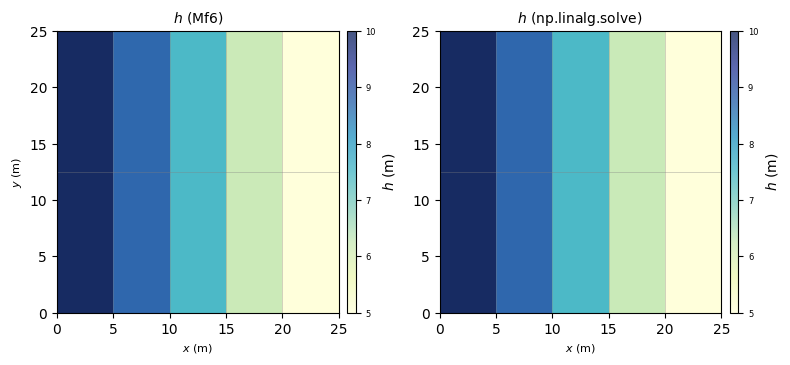

In [7]:
# --- Definición de la figura ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize =(8,4))

# --- Gráfica 1. ---
hview = flopy.plot.PlotMapView(model = o_gwf, ax = ax1)
hview.plot_grid(linewidths = 0.5, alpha = 0.5)
h_ac = hview.plot_array(head, cmap = "YlGnBu", vmin = hvmin, vmax = hvmax, alpha = 0.75)
h_cb = plt.colorbar(h_ac, ax = ax1, label = "$h$ (m)", cax = xmf6.vis.cax(ax1, h_ac))
h_cb.ax.tick_params(labelsize=6)
ax1.set_title("$h$ (Mf6)", fontsize=10)
ax1.set_ylabel("$y$ (m)", fontsize = 8)
ax1.set_xlabel("$x$ (m)", fontsize = 8)
ax1.set_aspect('equal')

# --- Gráfica 2. ---
sview = flopy.plot.PlotMapView(model = o_gwf, ax = ax2)
sview.plot_grid(linewidths = 0.5, alpha = 0.5)
s_ac = sview.plot_array(SOL.reshape((dis['nrow'], dis['ncol'])), cmap = "YlGnBu", vmin = hvmin, vmax = hvmax, alpha = 0.75)
s_cb = plt.colorbar(s_ac, ax = ax2, label = "$h$ (m)", cax = xmf6.vis.cax(ax2, s_ac))
s_cb.ax.tick_params(labelsize=6)
ax2.set_title("$h$ (np.linalg.solve) ", fontsize=10)
#ax2.set_ylabel("$y$ (m)", fontsize = 8)
ax2.set_xlabel("$x$ (m)", fontsize = 8)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()